In [ ]:
!pip install --upgrade pip
!pip install torch torchvision torchaudio pandas numpy librosa scikit-learn tqdm soundfile


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
# -*- coding: utf-8 -*-
"""
train_sound_model.py

A complete, self-contained script to train a simple CNN for sound classification
on the UrbanSound8K dataset. Optimized to run locally on Apple Silicon (M-series chips).
"""

import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION & PARAMETERS ---
print("🎧 Sound Classification Model Training Script 🎧")

# Paths (as specified by user)
METADATA_PATH = "/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K/metadata/UrbanSound8K.csv"
AUDIO_DIR = "/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K/audio"
OUTPUT_DIR = "output"

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Audio & Spectrogram Parameters
SR = 22050          # Sample Rate
DURATION = 4        # Duration of audio clips in seconds
SAMPLES = SR * DURATION
N_MELS = 128        # Number of Mel bands
HOP_LENGTH = 512    # Hop length for STFT
N_FFT = 2048        # Number of FFT components

# Model Training Parameters
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001

# --- 2. DEVICE CONFIGURATION (for Apple Silicon) ---
# Check for Apple's Metal Performance Shaders (MPS) and set it as the device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("\n✅ MPS device found. Training will run on your Mac's GPU.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("\n✅ CUDA device found. Training will run on your NVIDIA GPU.")
else:
    device = torch.device("cpu")
    print("\n⚠️ No GPU accelerator found. Training will run on the CPU (will be slower).")

# --- 3. DATA PREPROCESSING FUNCTION ---
def preprocess_audio(file_path):
    """
    Loads an audio file, pads/truncates it to a fixed length, and computes its
    log-mel spectrogram.
    """
    try:
        # Load audio file
        y, sr = librosa.load(file_path, sr=SR)

        # Pad or truncate to the fixed sample length
        if len(y) < SAMPLES:
            y = np.pad(y, (0, SAMPLES - len(y)), mode='constant')
        else:
            y = y[:SAMPLES]

        # Compute mel spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)

        # Convert to log scale (decibels)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

        return log_mel_spec
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# --- 4. LOADING & PROCESSING THE DATASET ---
# print("\n🔍 Loading metadata and processing audio files...")
# metadata = pd.read_csv(METADATA_PATH)

# features = []
# labels = []

# # Loop through the dataset with a progress bar
# for index, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Processing files"):
#     file_path = os.path.join(AUDIO_DIR, f"fold{row['fold']}", row['slice_file_name'])

#     # Check if file exists to prevent errors
#     if not os.path.exists(file_path):
#         print(f"File not found: {file_path}. Skipping.")
#         continue

#     # Preprocess the audio file to get the spectrogram
#     spectrogram = preprocess_audio(file_path)

#     if spectrogram is not None:
#         features.append(spectrogram)
#         labels.append(row['class'])

# print(f"\n✅ Processed {len(features)} audio files successfully.")

# # --- 5. DATA PREPARATION FOR PYTORCH ---
# print("\n⚙️ Preparing data for model training...")

# # Convert lists to NumPy arrays
# X = np.array(features)
# y = np.array(labels)

# # Encode string labels to integers
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)
# num_classes = len(le.classes_)
# print(f"Found {num_classes} classes: {list(le.classes_)}")

# # Add a channel dimension for the CNN (batch, channels, height, width)
# X = X[:, np.newaxis, :, :]

# # Split data into training and validation sets
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
# )

# # Convert NumPy arrays to PyTorch tensors
# X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train, dtype=torch.long)
# X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
# y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# # Create PyTorch Datasets and DataLoaders
# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 4. DATA LOADING & PREPROCESSING ---

print("\n🔍 Checking for preprocessed data...")
# Define paths for the saved NumPy arrays
FEATURES_PATH = os.path.join(OUTPUT_DIR, "processed_features.npy")
LABELS_PATH = os.path.join(OUTPUT_DIR, "processed_labels.npy")

# Check if the preprocessed files already exist
if os.path.exists(FEATURES_PATH) and os.path.exists(LABELS_PATH):
    print("✅ Preprocessed data found! Loading from disk...")
    X = np.load(FEATURES_PATH)
    y = np.load(LABELS_PATH, allow_pickle=True) # allow_pickle for string array
    print(f"Loaded {len(X)} features and labels.")

else:
    # If data doesn't exist, run the original processing loop
    print("⚠️ No preprocessed data found. Processing audio files from scratch...")
    metadata = pd.read_csv(METADATA_PATH)
    features, labels = [], []
    for index, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Processing files"):
        file_path = os.path.join(AUDIO_DIR, f"fold{row['fold']}", row['slice_file_name'])
        if not os.path.exists(file_path):
            print(f"File not found: {file_path}. Skipping.")
            continue
        spectrogram = preprocess_audio(file_path)
        if spectrogram is not None:
            features.append(spectrogram)
            labels.append(row['class'])

    # Convert lists to NumPy arrays
    X = np.array(features)
    y = np.array(labels)

    print(f"\n✅ Processed {len(X)} audio files successfully.")

    # Save the processed data to disk for the next time
    print(f"💾 Saving processed data to disk...")
    np.save(FEATURES_PATH, X)
    np.save(LABELS_PATH, y)
    print(f"Data saved to {FEATURES_PATH} and {LABELS_PATH}")


# --- 5. DATA PREPARATION FOR PYTORCH ---
# This section now starts with the assumption that X and y are already loaded or created.
print("\n⚙️ Preparing data for model training...")

# Encode string labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print(f"Found {num_classes} classes: {list(le.classes_)}")

# Add a channel dimension for the CNN (batch, channels, height, width)
X = X[:, np.newaxis, :, :]

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Create PyTorch Datasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 6. MODEL DEFINITION (Simple 2D CNN) ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        # Convolutional blocks (these are unchanged)
        self.conv_blocks = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # Block 2
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # Block 3
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        # Flatten layer
        self.flatten = nn.Flatten()

        # *** THE FIX IS HERE ***
        # Create a dummy input tensor to automatically calculate the flattened size.
        # This makes the model robust to changes in input dimensions.
        # We determine the number of time frames based on our audio parameters.
        time_frames = (SAMPLES // HOP_LENGTH) + 1
        dummy_input = torch.randn(1, 1, N_MELS, time_frames)
        dummy_output = self.conv_blocks(dummy_input)
        flattened_size = self.flatten(dummy_output).shape[1]

        # Fully Connected (Linear) Layer, now with the correct input size
        self.fc = nn.Linear(flattened_size, num_classes)

    def forward(self, x):
        # Pass input through the convolutional blocks
        x = self.conv_blocks(x)
        # Flatten the output for the linear layer
        x = self.flatten(x)
        # Pass through the final fully connected layer
        x = self.fc(x)
        return x
# Instantiate the model and move it to the configured device
model = SimpleCNN(num_classes).to(device)
print("\n📄 Model Summary:")
print(model)

# --- 7. TRAINING & VALIDATION LOOP ---
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"\n🚀 Starting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Use tqdm for a progress bar on the training loader
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for inputs, labels in train_pbar:
        # Move data to the device
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Update statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Update progress bar description
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct_train / total_train

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad(): # No need to calculate gradients during validation
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = correct_val / total_val

    print(
        f"Epoch {epoch+1}/{EPOCHS} -> "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

print("\n🎉 Training finished!")

# --- 8. SAVE THE MODEL AND LABEL ENCODER ---
model_save_path = os.path.join(OUTPUT_DIR, "sound_cnn_model.pth")
le_save_path = os.path.join(OUTPUT_DIR, "label_encoder.npy")

torch.save(model.state_dict(), model_save_path)
np.save(le_save_path, le.classes_)

print(f"\n💾 Model saved to: {model_save_path}")
print(f"💾 Label encoder classes saved to: {le_save_path}")
print("\n✅ All done!")

🎧 Sound Classification Model Training Script 🎧

✅ CUDA device found. Training will run on your NVIDIA GPU.

🔍 Checking for preprocessed data...
⚠️ No preprocessed data found. Processing audio files from scratch...


Processing files: 100%|██████████| 8732/8732 [2:15:48<00:00,  1.07it/s]



✅ Processed 8732 audio files successfully.
💾 Saving processed data to disk...
Data saved to output/processed_features.npy and output/processed_labels.npy

⚙️ Preparing data for model training...
Found 10 classes: [np.str_('air_conditioner'), np.str_('car_horn'), np.str_('children_playing'), np.str_('dog_bark'), np.str_('drilling'), np.str_('engine_idling'), np.str_('gun_shot'), np.str_('jackhammer'), np.str_('siren'), np.str_('street_music')]

📄 Model Summary:
SimpleCNN(
  (conv_blocks): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding

Epoch 1/20 [Val]: 100%|██████████| 55/55 [00:00<00:00, 159.14it/s]


Epoch 1/20 -> Train Loss: 2.1598, Train Acc: 0.5280 | Val Loss: 1.3963, Val Acc: 0.6027


...

Epoch 18/20 -> Train Loss: 0.0564, Train Acc: 0.9824 | Val Loss: 0.7059, Val Acc: 0.8443


Epoch 19/20 [Val]: 100%|██████████| 55/55 [00:00<00:00, 161.59it/s]


Epoch 19/20 -> Train Loss: 0.0482, Train Acc: 0.9867 | Val Loss: 1.3248, Val Acc: 0.7911


Epoch 20/20 [Val]: 100%|██████████| 55/55 [00:00<00:00, 150.78it/s]

Epoch 20/20 -> Train Loss: 0.1227, Train Acc: 0.9664 | Val Loss: 0.8604, Val Acc: 0.8351

🎉 Training finished!

💾 Model saved to: output/sound_cnn_model.pth
💾 Label encoder classes saved to: output/label_encoder.npy

✅ All done!


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mini1"
os.makedirs(SAVE_DIR, exist_ok=True)


In [ ]:
!cp /content/output/label_encoder.npy       "$SAVE_DIR/label_encoder.npy"
!cp /content/output/processed_features.npy  "$SAVE_DIR/processed_features.npy"
!cp /content/output/processed_labels.npy    "$SAVE_DIR/processed_labels.npy"
!cp /content/output/sound_cnn_model.pth     "$SAVE_DIR/sound_cnn_model.pth"


In [ ]:
# retrain_with_history.py
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- Paths ---
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mini1"
FEATURES_PATH = os.path.join(OUTPUT_DIR, "/content/drive/MyDrive/AKHIL_SOUND/mini1/processed_features.npy")
LABELS_PATH = os.path.join(OUTPUT_DIR, "/content/drive/MyDrive/AKHIL_SOUND/mini1/processed_labels.npy")
LE_PATH = os.path.join(OUTPUT_DIR, "/content/drive/MyDrive/AKHIL_SOUND/mini1/label_encoder.npy")

# --- Parameters ---
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Load Data ---
X = np.load(FEATURES_PATH)
y = np.load(LABELS_PATH, allow_pickle=True)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

# Save label encoder classes
np.save(LE_PATH, le.classes_)

# Add channel dimension
X = X[:, np.newaxis, :, :]

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=BATCH_SIZE, shuffle=False)

# --- Model Definition ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes, input_shape):
        super(SimpleCNN, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.flatten = nn.Flatten()
        dummy_input = torch.randn(1, 1, input_shape[2], input_shape[3])
        dummy_output = self.conv_blocks(dummy_input)
        flattened_size = self.flatten(dummy_output).shape[1]
        self.fc = nn.Linear(flattened_size, num_classes)

    def forward(self, x):
        x = self.conv_blocks(x)
        x = self.flatten(x)
        return self.fc(x)

# Instantiate model
model = SimpleCNN(num_classes, X.shape).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- Training ---
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
print(f"\n🚀 Retraining for {EPOCHS} epochs (history will be saved)...")

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0, 0, 0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct_train / total_train

    # Validation
    model.eval()
    val_loss, correct_val, total_val = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct_val / total_val

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

# Save history
np.save(os.path.join(OUTPUT_DIR, "training_history.npy"), history)
print("💾 Training history saved!")

# --- Final Evaluation ---
y_true, y_pred, y_prob = [], [], []
model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

np.save(os.path.join(OUTPUT_DIR, "y_true.npy"), y_true)
np.save(os.path.join(OUTPUT_DIR, "y_pred.npy"), y_pred)
np.save(os.path.join(OUTPUT_DIR, "y_prob.npy"), y_prob)

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.close()

print("\n✅ Metrics, history, and confusion matrix saved (model not overwritten).")


Using device: cuda

🚀 Retraining for 20 epochs (history will be saved)...


Epoch 1/20 [Train]: 100%|██████████| 219/219 [00:03<00:00, 59.63it/s]


Epoch 1: Train Acc=0.5201, Val Acc=0.6400


Epoch 2/20 [Train]: 100%|██████████| 219/219 [00:03<00:00, 62.39it/s]


Epoch 2: Train Acc=0.7142, Val Acc=0.6898


...

Epoch 18: Train Acc=0.9903, Val Acc=0.8878


Epoch 19/20 [Train]: 100%|██████████| 219/219 [00:03<00:00, 59.46it/s]


Epoch 19: Train Acc=0.9666, Val Acc=0.8523


Epoch 20/20 [Train]: 100%|██████████| 219/219 [00:03<00:00, 62.24it/s]


Epoch 20: Train Acc=0.9764, Val Acc=0.8294
💾 Training history saved!

Classification Report:
                  precision    recall  f1-score   support

 air_conditioner       0.85      0.88      0.86       200
        car_horn       0.85      0.94      0.90        86
children_playing       0.98      0.45      0.61       200
        dog_bark       0.81      0.87      0.84       200
        drilling       0.82      0.92      0.86       200
   engine_idling       0.94      0.76      0.84       200
        gun_shot       0.82      1.00      0.90        75
      jackhammer       0.97      0.88      0.92       200
           siren       0.90      0.85      0.88       186
    street_music       0.61      0.93      0.74       200

        accuracy                           0.83      1747
       macro avg       0.85      0.85      0.83      1747
    weighted avg       0.86      0.83      0.83      1747


✅ Metrics, history, and confusion matrix saved (model not overwritten).


In [ ]:
# -*- coding: utf-8 -*-
"""
predict_sound.py (Updated)

A script to load the trained model and predict the class of an audio file
from the UrbanSound8K dataset, comparing it to the actual class.
"""

import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn

# --- 1. CONFIGURATION ---
print("🎤 Sound Classification Prediction & Verification Script 🎤")

# --- CHANGE THIS ---
# Relative path of the file from within the 'UrbanSound8K/audio/' folder.
# Example files you can try:
# "fold5/100032-3-0-0.wav"  (should be 'dog_bark')
# "fold1/101415-3-0-2.wav"  (should be 'dog_bark')
# "fold10/104817-4-0-0.wav" (should be 'drilling')
# "fold2/107853-5-0-0.wav"  (should be 'engine_idling')
AUDIO_TO_TEST_RELATIVE = "/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K/audio/fold10/100648-1-0-0.wav"

# Paths to model, labels, and metadata
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mini1"
MODEL_PATH = os.path.join(OUTPUT_DIR, "sound_cnn_model.pth")
LE_PATH = os.path.join(OUTPUT_DIR, "label_encoder.npy")
METADATA_PATH = "/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K/metadata/UrbanSound8K.csv"
AUDIO_ROOT = "/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K/audio"
AUDIO_ROOT = ""

# Audio parameters (MUST match the parameters from training)
SR = 22050
DURATION = 4
SAMPLES = SR * DURATION
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048

# --- 2. SETUP DEVICE, MODEL CLASS, AND HELPER FUNCTIONS ---
# Check for MPS device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("\n✅ MPS device found. Using GPU for inference.")
else:
    device = torch.device("cpu")
    print("\n⚠️ No GPU found. Using CPU for inference.")

# Re-define the exact same model architecture used for training
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.flatten = nn.Flatten()
        time_frames = (SAMPLES // HOP_LENGTH) + 1
        dummy_input = torch.randn(1, 1, N_MELS, time_frames)
        dummy_output = self.conv_blocks(dummy_input)
        flattened_size = self.flatten(dummy_output).shape[1]
        self.fc = nn.Linear(flattened_size, num_classes)

    def forward(self, x):
        x = self.conv_blocks(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

# Define the same preprocessing function used in training
def preprocess_audio(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SR)
        if len(y) < SAMPLES: y = np.pad(y, (0, SAMPLES - len(y)))
        else: y = y[:SAMPLES]
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        return librosa.power_to_db(mel_spec, ref=np.max)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def get_actual_class(relative_path, metadata_df):
    """Looks up the true class label from the metadata DataFrame."""
    filename = os.path.basename(relative_path)
    file_metadata = metadata_df[metadata_df['slice_file_name'] == filename]
    if not file_metadata.empty:
        return file_metadata.iloc[0]['class']
    return "Unknown (file not in metadata)"


# --- 3. LOAD MODEL AND MAKE PREDICTION ---
def predict(audio_path, model, classes):
    """Predicts the sound class for a single audio file."""
    model.eval()
    spectrogram = preprocess_audio(audio_path)
    if spectrogram is None: return None, None

    spec_tensor = torch.tensor(spectrogram, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    spec_tensor = spec_tensor.to(device)

    with torch.no_grad():
        output = model(spec_tensor)

    probabilities = torch.nn.functional.softmax(output, dim=1)
    confidence, predicted_idx = torch.max(probabilities, 1)

    predicted_class = classes[predicted_idx.item()]
    confidence_percent = confidence.item() * 100

    return predicted_class, confidence_percent

# Main execution block
if __name__ == "__main__":
    # Construct the full path to the audio file
    full_audio_path = os.path.join(AUDIO_ROOT, AUDIO_TO_TEST_RELATIVE)

    if not os.path.exists(full_audio_path):
        print(f"❌ Error: Audio file not found at '{full_audio_path}'")
        print("Please check the AUDIO_TO_TEST_RELATIVE variable.")
    else:
        # Load metadata, label encoder, and the trained model
        metadata = pd.read_csv(METADATA_PATH)
        le_classes = np.load(LE_PATH, allow_pickle=True)
        num_classes = len(le_classes)

        model = SimpleCNN(num_classes)
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        model.to(device)

        # Get the actual class from the metadata
        actual_class = get_actual_class(AUDIO_TO_TEST_RELATIVE, metadata)

        # Get the model's prediction
        predicted_class, confidence = predict(full_audio_path, model, le_classes)

        # Print the final comparison
        print("\n-------------------------------------------")
        print(f"🔊 Analysis for: {AUDIO_TO_TEST_RELATIVE}")
        print(f"    - ✅ Actual Class:    '{actual_class}'")
        if predicted_class:
            print(f"    - 🤖 Predicted Class: '{predicted_class}' (Confidence: {confidence:.2f}%)")
        else:
            print("    - 🤖 Prediction failed.")
        print("-------------------------------------------")

🎤 Sound Classification Prediction & Verification Script 🎤

⚠️ No GPU found. Using CPU for inference.

-------------------------------------------
🔊 Analysis for: /content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K/audio/fold10/100648-1-0-0.wav
    - ✅ Actual Class:    'car_horn'
    - 🤖 Predicted Class: 'car_horn' (Confidence: 99.91%)
-------------------------------------------


part2


In [ ]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
from tqdm import tqdm

# --- CONFIGURATION ---
print("🔊 Creating Multi-Source Audio Dataset 🔊")
INPUT_METADATA = "/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K/metadata/UrbanSound8K.csv"
INPUT_AUDIO_DIR = "/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K/audio"
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mini2/mixed_dataset"
OUTPUT_AUDIO_DIR = os.path.join(OUTPUT_DIR, "audio")

NUM_SYNTHETIC_FILES = 2000 # Number of mixed audio files to generate
NUM_SOURCES_MIN = 2        # Mix at least 2 sounds
NUM_SOURCES_MAX = 3        # Mix at most 3 sounds

# Audio parameters
SR = 22050
DURATION = 4
SAMPLES = SR * DURATION

# Create output directories
os.makedirs(OUTPUT_AUDIO_DIR, exist_ok=True)

# --- SCRIPT ---
metadata = pd.read_csv(INPUT_METADATA)
# Get a list of unique classes to create multi-hot labels later
class_list = sorted(metadata['class'].unique())
class_to_int = {cls: i for i, cls in enumerate(class_list)}

new_metadata = []

for i in tqdm(range(NUM_SYNTHETIC_FILES), desc="Generating mixed audio"):
    num_sources = np.random.randint(NUM_SOURCES_MIN, NUM_SOURCES_MAX + 1)

    # Select unique files from different classes
    selected_rows = metadata.groupby('classID').sample(1)
    selected_rows = selected_rows.sample(n=num_sources)

    mixed_audio = np.zeros(SAMPLES, dtype=np.float32)
    present_classes = set()

    for _, row in selected_rows.iterrows():
        try:
            # Load and preprocess audio
            file_path = os.path.join(INPUT_AUDIO_DIR, f"fold{row['fold']}", row['slice_file_name'])
            y, sr = librosa.load(file_path, sr=SR)

            # Pad or truncate
            if len(y) < SAMPLES:
                y = np.pad(y, (0, SAMPLES - len(y)))
            else:
                y = y[:SAMPLES]

            # Normalize volume before mixing
            y /= np.max(np.abs(y)) + 1e-8

            mixed_audio += y
            present_classes.add(row['class'])

        except Exception as e:
            print(f"Skipping file {row['slice_file_name']} due to error: {e}")
            continue

    # Normalize the final mixed audio to prevent clipping
    mixed_audio /= np.max(np.abs(mixed_audio)) + 1e-8

    # Create multi-hot encoded label
    label_vector = [0] * len(class_list)
    for cls in present_classes:
        label_vector[class_to_int[cls]] = 1

    # Save audio and metadata
    output_filename = f"mixed_{i:04d}.wav"
    output_path = os.path.join(OUTPUT_AUDIO_DIR, output_filename)
    sf.write(output_path, mixed_audio, SR)

    # The label vector is stored as a string for easy CSV saving
    new_metadata.append({
        "filename": output_filename,
        "classes": ','.join(map(str, label_vector))
    })

# Save the new metadata file
df_new = pd.DataFrame(new_metadata)
df_new.to_csv(os.path.join(OUTPUT_DIR, "metadata.csv"), index=False)

print(f"\n✅ Successfully created {NUM_SYNTHETIC_FILES} mixed audio files in '{OUTPUT_DIR}'")

🔊 Creating Multi-Source Audio Dataset 🔊


Generating mixed audio: 100%|██████████| 2000/2000 [02:43<00:00, 12.22it/s]


✅ Successfully created 2000 mixed audio files in '/content/drive/MyDrive/AKHIL_SOUND/mini2/mixed_dataset'


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import librosa
import json
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
print("🧠 Training Multi-Label Sound Event Detection Model 🧠")
DATA_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mini2/mixed_dataset"
METADATA_PATH = os.path.join(DATA_DIR, "metadata.csv")
AUDIO_DIR = os.path.join(DATA_DIR, "audio")
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mini2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Audio parameters
SR = 22050
DURATION = 4
SAMPLES = SR * DURATION
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
NUM_CLASSES = 10 # From UrbanSound8K

# Training parameters
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.001

# --- SETUP DEVICE & MODEL ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"\nUsing device: {device}")

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.flatten = nn.Flatten()
        time_frames = (SAMPLES // HOP_LENGTH) + 1
        dummy_input = torch.randn(1, 1, N_MELS, time_frames)
        dummy_output = self.conv_blocks(dummy_input)
        flattened_size = self.flatten(dummy_output).shape[1]
        self.fc = nn.Linear(flattened_size, num_classes)

    def forward(self, x):
        x = self.conv_blocks(x)
        x = self.flatten(x)
        return self.fc(x)

class MixedSoundDataset(Dataset):
    def __init__(self, df, audio_dir):
        self.df = df
        self.audio_dir = audio_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.audio_dir, row['filename'])
        y, sr = librosa.load(file_path, sr=SR)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        label = np.array([float(x) for x in row['classes'].split(',')])
        return torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0), torch.tensor(label, dtype=torch.float32)

metadata = pd.read_csv(METADATA_PATH)
train_df, val_df = train_test_split(metadata, test_size=0.2, random_state=42)

train_dataset = MixedSoundDataset(train_df, AUDIO_DIR)
val_dataset = MixedSoundDataset(val_df, AUDIO_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- TRAINING LOOP ---
model = SimpleCNN(NUM_CLASSES).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "val_loss": [], "val_acc": []}

print(f"\n🚀 Starting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    correct_preds, total_preds = 0, 0
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            probs = torch.sigmoid(outputs)
            preds = probs > 0.5

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

            total_preds += labels.numel()
            correct_preds += (preds == labels.bool()).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = correct_preds / total_preds

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# --- SAVE EVERYTHING ---
# 1. Model (as before)
model_save_path = os.path.join(OUTPUT_DIR, "multi_label_cnn_model.pth")
torch.save(model.state_dict(), model_save_path)
print(f"\n✅ Model saved to '{model_save_path}'")

# 2. Training history
history_path = os.path.join(OUTPUT_DIR, "training_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=4)
print(f"📊 Training history saved to '{history_path}'")

# 3. Predictions
np.save(os.path.join(OUTPUT_DIR, "y_true.npy"), np.array(y_true))
np.save(os.path.join(OUTPUT_DIR, "y_pred.npy"), np.array(y_pred))
np.save(os.path.join(OUTPUT_DIR, "y_prob.npy"), np.array(y_prob))
print("✅ Predictions saved (y_true, y_pred, y_prob)")

# 4. Classification report
report = classification_report(
    np.array(y_true),
    np.array(y_pred),
    target_names=[f"class_{i}" for i in range(NUM_CLASSES)],
    zero_division=0
)
with open(os.path.join(OUTPUT_DIR, "classification_report.txt"), "w") as f:
    f.write(report)
print("📄 Classification report saved")

# 5. Confusion matrices per class
cms = multilabel_confusion_matrix(np.array(y_true), np.array(y_pred))
for i, cm in enumerate(cms):
    plt.figure()
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Class {i}")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_matrix_class_{i}.png"))
    plt.close()
print("📊 Per-class confusion matrices saved")

# 6. Combined confusion matrix (all classes at once)
# Convert multi-label problem into single-label by treating each class as independent samples
y_true_flat = np.array(y_true).ravel()
y_pred_flat = np.array(y_pred).ravel()

cm_all = confusion_matrix(y_true_flat, y_pred_flat)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_all, annot=True, fmt="d", cmap="Blues", xticklabels=["0", "1"], yticklabels=["0", "1"])
plt.title("Combined Confusion Matrix (All Classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_all_classes.png"))
plt.close()
print("📊 Combined confusion matrix saved")

🧠 Training Multi-Label Sound Event Detection Model 🧠

Using device: cpu

🚀 Starting training for 25 epochs...


Epoch 1/25 [Train]: 100%|██████████| 50/50 [02:00<00:00,  2.40s/it]


Epoch 1/25 -> Train Loss: 0.9637 | Val Loss: 0.5459, Val Acc: 0.7492


Epoch 2/25 [Train]: 100%|██████████| 50/50 [01:42<00:00,  2.06s/it]


Epoch 2/25 -> Train Loss: 0.5296 | Val Loss: 0.4787, Val Acc: 0.7910


...

Epoch 23/25 -> Train Loss: 0.0118 | Val Loss: 0.6462, Val Acc: 0.8395


Epoch 24/25 [Train]: 100%|██████████| 50/50 [01:44<00:00,  2.09s/it]


Epoch 24/25 -> Train Loss: 0.0202 | Val Loss: 0.6064, Val Acc: 0.8297


Epoch 25/25 [Train]: 100%|██████████| 50/50 [01:50<00:00,  2.22s/it]


Epoch 25/25 -> Train Loss: 0.0204 | Val Loss: 0.6215, Val Acc: 0.8317

✅ Model saved to '/content/drive/MyDrive/AKHIL_SOUND/mini2/multi_label_cnn_model.pth'
📊 Training history saved to '/content/drive/MyDrive/AKHIL_SOUND/mini2/training_history.json'
✅ Predictions saved (y_true, y_pred, y_prob)
📄 Classification report saved
📊 Per-class confusion matrices saved
📊 Combined confusion matrix saved


In [ ]:
# -*- coding: utf-8 -*-
"""
3_test_multi_label_model.py

A script to test the trained multi-label sound event detection model.
It loads a mixed audio file, predicts which sounds are present, and
compares the prediction to the actual ground truth.
"""

import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn

# --- 1. CONFIGURATION ---
print("🎤 Multi-Label Sound Event Detection - Test Script 🎤")

# --- CHANGE THIS ---
# Path to the mixed audio file you want to test.
AUDIO_TO_TEST = "/content/drive/MyDrive/AKHIL_SOUND/mixed_dataset/audio/mixed_0000.wav"

# --- FIXED PATHS & PARAMETERS ---
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mini2"
DATA_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mixed_dataset"
MODEL_PATH = os.path.join(OUTPUT_DIR, "multi_label_cnn_model.pth")
LE_PATH =  "/content/drive/MyDrive/AKHIL_SOUND/mini1/label_encoder.npy"#For class names
METADATA_PATH = os.path.join(DATA_DIR, "/content/drive/MyDrive/AKHIL_SOUND/mixed_dataset/metadata.csv")

# Audio parameters (MUST match training script)
SR = 22050
DURATION = 4
SAMPLES = SR * DURATION
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
NUM_CLASSES = 10

# Prediction threshold: A sound is considered "present" if its probability is above this value.
PREDICTION_THRESHOLD = 0.5

# --- 2. SETUP DEVICE, MODEL, AND HELPERS ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Re-define the exact same model architecture
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.flatten = nn.Flatten()
        time_frames = (SAMPLES // HOP_LENGTH) + 1
        dummy_input = torch.randn(1, 1, N_MELS, time_frames)
        dummy_output = self.conv_blocks(dummy_input)
        flattened_size = self.flatten(dummy_output).shape[1]
        self.fc = nn.Linear(flattened_size, num_classes)

    def forward(self, x):
        x = self.conv_blocks(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

# Preprocessing function
def preprocess_audio(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SR)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        return librosa.power_to_db(mel_spec, ref=np.max)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# --- 3. MAIN PREDICTION BLOCK ---
if __name__ == "__main__":
    if not os.path.exists(AUDIO_TO_TEST):
        print(f"❌ Error: Audio file not found at '{AUDIO_TO_TEST}'")
    else:
        # Load metadata, class names, and the trained model
        metadata = pd.read_csv(METADATA_PATH)
        class_names = np.load(LE_PATH, allow_pickle=True)

        model = SimpleCNN(NUM_CLASSES)
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        model.to(device)
        model.eval()

        # --- Get Actual Sounds ---
        filename = os.path.basename(AUDIO_TO_TEST)
        file_meta = metadata[metadata['filename'] == filename]

        if file_meta.empty:
            print(f"Could not find metadata for {filename}")
            actual_sounds = []
        else:
            actual_labels_vector = np.array([int(x) for x in file_meta.iloc[0]['classes'].split(',')])
            actual_sounds = [class_names[i] for i, present in enumerate(actual_labels_vector) if present == 1]

        # --- Get Predicted Sounds ---
        spectrogram = preprocess_audio(AUDIO_TO_TEST)
        spec_tensor = torch.tensor(spectrogram, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(spec_tensor)
            # Apply sigmoid to convert logits to independent probabilities
            probabilities = torch.sigmoid(logits).cpu().numpy()[0]

        predicted_sounds = []
        confidences = []
        for i, prob in enumerate(probabilities):
            if prob > PREDICTION_THRESHOLD:
                predicted_sounds.append(class_names[i])
                confidences.append(prob)

        # --- Display Results ---
        print("\n" + "="*50)
        print(f"ANALYSIS FOR: {filename}")
        print("="*50)

        print("\n✅ ACTUAL SOUNDS:")
        if actual_sounds:
            for sound in sorted(actual_sounds):
                print(f"  - {sound}")
        else:
            print("  - (None found in metadata)")

        print("\n🤖 PREDICTED SOUNDS:")
        if predicted_sounds:
            for sound, conf in sorted(zip(predicted_sounds, confidences)):
                print(f"  - {sound} (Confidence: {conf*100:.2f}%)")
        else:
            print("  - (None detected)")
        print("\n" + "="*50)

🎤 Multi-Label Sound Event Detection - Test Script 🎤

Using device: cpu

ANALYSIS FOR: mixed_0000.wav

✅ ACTUAL SOUNDS:
  - children_playing
  - dog_bark
  - siren

🤖 PREDICTED SOUNDS:
  - children_playing (Confidence: 99.78%)
  - dog_bark (Confidence: 99.76%)
  - siren (Confidence: 99.89%)



part3


In [ ]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("🔊 Creating a Dataset for Audio Separation 🔊")

# --- CONFIGURATION ---
INPUT_METADATA = "/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K/metadata/UrbanSound8K.csv"
INPUT_AUDIO_DIR = "/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K/audio"
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K_separation"
OUTPUT_AUDIO_DIR = os.path.join(OUTPUT_DIR, "audio")

NUM_SYNTHETIC_FILES = 2000
NUM_SOURCES_MIN = 2
NUM_SOURCES_MAX = 3
SR = 22050
DURATION = 4
SAMPLES = SR * DURATION

os.makedirs(OUTPUT_AUDIO_DIR, exist_ok=True)
metadata = pd.read_csv(INPUT_METADATA)
new_metadata = []

for i in tqdm(range(NUM_SYNTHETIC_FILES), desc="Generating mixed audio"):
    num_sources = np.random.randint(NUM_SOURCES_MIN, NUM_SOURCES_MAX + 1)
    selected_rows = metadata.groupby('classID').sample(1).sample(n=num_sources)

    mixed_audio = np.zeros(SAMPLES, dtype=np.float32)
    source_paths = []

    for _, row in selected_rows.iterrows():
        file_path = os.path.join(INPUT_AUDIO_DIR, f"fold{row['fold']}", row['slice_file_name'])
        y, _ = librosa.load(file_path, sr=SR)
        if len(y) < SAMPLES: y = np.pad(y, (0, SAMPLES - len(y)))
        else: y = y[:SAMPLES]

        y /= np.max(np.abs(y)) + 1e-8
        mixed_audio += y
        source_paths.append(file_path) # Store the path to the clean source

    mixed_audio /= np.max(np.abs(mixed_audio)) + 1e-8

    output_filename = f"mixed_sep_{i:04d}.wav"
    output_path = os.path.join(OUTPUT_AUDIO_DIR, output_filename)
    sf.write(output_path, mixed_audio, SR)

    new_metadata.append({
        "mix_filename": output_filename,
        "source_paths": ';'.join(source_paths) # Use a separator for the paths
    })

df_new = pd.DataFrame(new_metadata)
df_new.to_csv(os.path.join(OUTPUT_DIR, "metadata.csv"), index=False)

print(f"\n✅ Successfully created separation dataset in '{OUTPUT_DIR}'")

🔊 Creating a Dataset for Audio Separation 🔊


Generating mixed audio: 100%|██████████| 2000/2000 [47:40<00:00,  1.43s/it]


✅ Successfully created separation dataset in '/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K_separation'


In [ ]:
import os
os.chdir("/content/drive/MyDrive/AKHIL_SOUND")


In [ ]:
!ls


1_create_mixed_dataset.py     mini1		train_separation_model.py
2_train_multi_label_model.py  mini2		train_sound_model.py
3_test_multi_label_model.py   mixed_dataset	UrbanSound8K
best_separation_model.pth     predict_sound.py	UrbanSound8K_separation


In [ ]:
!pip install torch torchvision torchaudio librosa soundfile pandas scikit-learn tqdm


In [ ]:
import os
import numpy as np
import torch
import librosa
import soundfile as sf
# Make sure you have renamed the training script to 'train_separation_model.py'
from train_separation_model import UNet

print("✨ Audio Separation Script ✨")

# --- 1. CONFIGURATION ---

# --- EDIT THESE TWO LINES ---
MIXED_AUDIO_PATH = "/content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K_separation/audio/mixed_sep_0048.wav"
CLASS_TO_REMOVE = "siren"
# ---------------------------

OUTPUT_FILENAME = "output_separated.wav"

# --- FIXED PATHS & PARAMETERS ---
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND"
MODEL_PATH = os.path.join(OUTPUT_DIR, "best_separation_model.pth")
LE_PATH = "/content/drive/MyDrive/AKHIL_SOUND/output/label_encoder.npy"
SR = 22050
N_FFT = 2048
HOP_LENGTH = 512
NUM_CLASSES = 10

# --- 2. SETUP ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"\nUsing device: {device}")

class_names = np.load(LE_PATH, allow_pickle=True)
class_to_idx = {name: i for i, name in enumerate(class_names)}

if CLASS_TO_REMOVE not in class_to_idx:
    raise ValueError(f"Error: Class '{CLASS_TO_REMOVE}' not found. Please choose from: {class_names}")

model = UNet(n_class=NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

# --- 3. SEPARATION PROCESS ---
try:
    print(f"Loading mixed audio: {MIXED_AUDIO_PATH}")
    y_mix, _ = librosa.load(MIXED_AUDIO_PATH, sr=SR)

    s_mix_full = librosa.stft(y_mix, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mag_mix, phase_mix = librosa.magphase(s_mix_full)

    mag_mix_tensor = torch.tensor(mag_mix, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    print("Generating source masks...")
    with torch.no_grad():
        predicted_masks = model(mag_mix_tensor)

    remove_idx = class_to_idx[CLASS_TO_REMOVE]
    print(f"Applying inverted mask for '{CLASS_TO_REMOVE}'...")
    mask_to_remove = predicted_masks[0, remove_idx, :, :].cpu().numpy()

    final_mask = 1 - mask_to_remove

    # *** THIS IS THE FIX ***
    # Crop the original magnitude and phase to match the mask's (model's output) size.
    target_H, target_W = final_mask.shape
    mag_mix_cropped = mag_mix[:target_H, :target_W]
    phase_mix_cropped = phase_mix[:target_H, :target_W]
    # ***********************

    # Apply the mask to the CROPPED original magnitude
    mag_final = mag_mix_cropped * final_mask

    print("Reconstructing audio from the modified spectrogram...")
    # Reconstruct using the new magnitude and the CROPPED original phase
    y_final = librosa.istft(mag_final * phase_mix_cropped, hop_length=HOP_LENGTH)

    sf.write(OUTPUT_FILENAME, y_final, SR)
    print(f"\n✅ Separation complete! Audio saved to '{OUTPUT_FILENAME}'")

except Exception as e:
    print(f"\nAn error occurred: {e}")

🧠 Training U-Net with Perceptual SI-SDR Loss & Checkpointing 🧠

Using device: cpu
✨ Audio Separation Script ✨

Using device: cpu
Loading mixed audio: /content/drive/MyDrive/AKHIL_SOUND/UrbanSound8K_separation/audio/mixed_sep_0048.wav
Generating source masks...
Applying inverted mask for 'siren'...
Reconstructing audio from the modified spectrogram...

✅ Separation complete! Audio saved to 'output_separated.wav'


MINI1 CRNN EFFICIENET NETBO


🎧 CRNN Model Training Script (with History Saving) 🎧

✅ CUDA device found. Training will run on your NVIDIA GPU.

🔍 Loading pre-processed data from disk...
✅ Loaded 8732 features and labels successfully.

⚙️ Preparing data for model training...
Found 10 classes: [np.str_('air_conditioner'), np.str_('car_horn'), np.str_('children_playing'), np.str_('dog_bark'), np.str_('drilling'), np.str_('engine_idling'), np.str_('gun_shot'), np.str_('jackhammer'), np.str_('siren'), np.str_('street_music')]

📄 CRNN Model Summary:
CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): M

Epoch 1/20 [Val]: 100%|██████████| 55/55 [00:00<00:00, 108.72it/s]


Epoch 1/20 -> Train Loss: 1.4626, Train Acc: 0.4596 | Val Loss: 1.2310, Val Acc: 0.5518


Epoch 2/20 [Val]: 100%|██████████| 55/55 [00:00<00:00, 109.30it/s]


Epoch 2/20 -> Train Loss: 1.0286, Train Acc: 0.6435 | Val Loss: 0.9668, Val Acc: 0.6760


...

Epoch 18/20 -> Train Loss: 0.0459, Train Acc: 0.9857 | Val Loss: 0.3479, Val Acc: 0.9038


Epoch 19/20 [Val]: 100%|██████████| 55/55 [00:00<00:00, 104.54it/s]


Epoch 19/20 -> Train Loss: 0.0340, Train Acc: 0.9895 | Val Loss: 0.3235, Val Acc: 0.9199


Epoch 20/20 [Val]: 100%|██████████| 55/55 [00:00<00:00, 114.06it/s]


Epoch 20/20 -> Train Loss: 0.0324, Train Acc: 0.9904 | Val Loss: 0.3010, Val Acc: 0.9256

🎉 Training finished!

💾 CRNN Model saved to: /content/drive/MyDrive/AKHIL_SOUND/output/1crnn/crnn_sound_model.pth
💾 Saving training history...
✅ History saved to 'output/crnn_training_history.csv'
📊 Generating and saving plots...
✅ Training curves plot saved to '/content/drive/MyDrive/AKHIL_SOUND/output/1crnn/crnn_training_curves.png'

✅ All done!


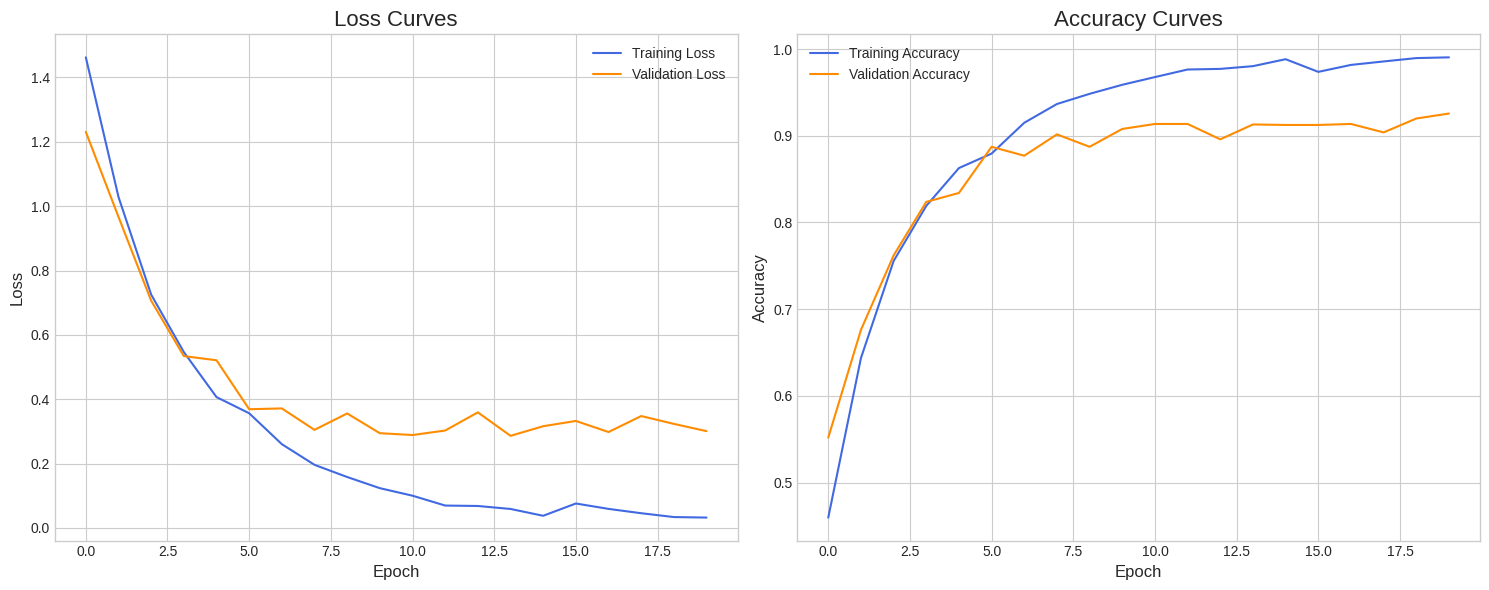

In [ ]:
# -*- coding: utf-8 -*-
"""
train_crnn_model.py (with history saving)

A script to train a CRNN model and save the model, training history, and plots.
"""

import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION & PARAMETERS ---
print("🎧 CRNN Model Training Script (with History Saving) 🎧")
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/output/1crnn"
N_MELS = 128
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001

# --- 2. DEVICE CONFIGURATION ---
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("\n✅ MPS device found. Training will run on your Mac's GPU.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("\n✅ CUDA device found. Training will run on your NVIDIA GPU.")
else:
    device = torch.device("cpu")
    print("\n⚠️ No GPU accelerator found. Training will run on the CPU.")

# --- 4. LOAD PRE-PROCESSED DATA ---
print("\n🔍 Loading pre-processed data from disk...")
FEATURES_PATH = os.path.join("/content/drive/MyDrive/AKHIL_SOUND/mini1/processed_features.npy")
LABELS_PATH = os.path.join("/content/drive/MyDrive/AKHIL_SOUND/mini1/processed_labels.npy")

if not os.path.exists(FEATURES_PATH) or not os.path.exists(LABELS_PATH):
    print(f"❌ Error: Pre-processed data not found at '{OUTPUT_DIR}'.")
    print("Please run the original 'train_sound_model.py' script first to generate these files.")
    sys.exit()

X = np.load(FEATURES_PATH)
y = np.load(LABELS_PATH, allow_pickle=True)
print(f"✅ Loaded {len(X)} features and labels successfully.")


# --- 5. DATA PREPARATION FOR PYTORCH ---
print("\n⚙️ Preparing data for model training...")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print(f"Found {num_classes} classes: {list(le.classes_)}")
X = X[:, np.newaxis, :, :]
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


# --- 6. MODEL DEFINITION (CRNN) ---
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d((2, 1)),
        )
        lstm_input_size = 64 * (N_MELS // 8)
        self.lstm = nn.LSTM(input_size=lstm_input_size, hidden_size=128, num_layers=2,
                            batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128 * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 3, 1, 2)
        b, t, c, h = x.size()
        x = x.view(b, t, -1)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.fc(x)
        return x

model = CRNN(num_classes).to(device)
print("\n📄 CRNN Model Summary:")
print(model)


# --- 7. TRAINING & VALIDATION LOOP ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ** NEW: Lists to store training history **
history = { "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [] }

print(f"\n🚀 Starting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct_train / total_train

    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct_val / total_val

    print(
        f"Epoch {epoch+1}/{EPOCHS} -> "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    # ** NEW: Append epoch results to history **
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

print("\n🎉 Training finished!")

# --- 8. SAVE THE TRAINED CRNN MODEL ---
model_save_path = os.path.join(OUTPUT_DIR, "crnn_sound_model.pth")
le_save_path = os.path.join(OUTPUT_DIR, "label_encoder.npy")
torch.save(model.state_dict(), model_save_path)
np.save(le_save_path, le.classes_)
print(f"\n💾 CRNN Model saved to: {model_save_path}")

# --- 9. SAVE TRAINING HISTORY & PLOTS ---
print("💾 Saving training history...")
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, "crnn_training_history.csv"), index=False)
print("✅ History saved to 'output/crnn_training_history.csv'")

print("📊 Generating and saving plots...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Loss
ax1.plot(history_df['train_loss'], label='Training Loss', color='royalblue')
ax1.plot(history_df['val_loss'], label='Validation Loss', color='darkorange')
ax1.set_title('Loss Curves', fontsize=16)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()

# Plot Accuracy
ax2.plot(history_df['train_acc'], label='Training Accuracy', color='royalblue')
ax2.plot(history_df['val_acc'], label='Validation Accuracy', color='darkorange')
ax2.set_title('Accuracy Curves', fontsize=16)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend()

fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "crnn_training_curves.png"))
print(f"✅ Training curves plot saved to '{os.path.join(OUTPUT_DIR, 'crnn_training_curves.png')}'")
print("\n✅ All done!")

In [ ]:
pip install timm

🎧 EfficientNet (Transfer Learning) Model Training Script 🎧

✅ CUDA device found. Training will run on your NVIDIA GPU.

🔍 Loading pre-processed data from disk...
✅ Loaded 8732 features and labels successfully.

⚙️ Preparing data for model training...
Found 10 classes: [np.str_('air_conditioner'), np.str_('car_horn'), np.str_('children_playing'), np.str_('dog_bark'), np.str_('drilling'), np.str_('engine_idling'), np.str_('gun_shot'), np.str_('jackhammer'), np.str_('siren'), np.str_('street_music')]


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


📄 EfficientNet Model Summary:

🚀 Starting training for 20 epochs...


Epoch 1/20 [Val]: 100%|██████████| 55/55 [00:01<00:00, 43.43it/s]


Epoch 1/20 -> Train Loss: 0.6313, Train Acc: 0.8063 | Val Loss: 0.3380, Val Acc: 0.8935


...

Epoch 18/20 -> Train Loss: 0.0545, Train Acc: 0.9815 | Val Loss: 0.1773, Val Acc: 0.9565


Epoch 19/20 [Val]: 100%|██████████| 55/55 [00:01<00:00, 50.85it/s]


Epoch 19/20 -> Train Loss: 0.0557, Train Acc: 0.9798 | Val Loss: 0.1211, Val Acc: 0.9662


Epoch 20/20 [Val]: 100%|██████████| 55/55 [00:01<00:00, 44.86it/s]


Epoch 20/20 -> Train Loss: 0.0254, Train Acc: 0.9923 | Val Loss: 0.1666, Val Acc: 0.9616

🎉 Training finished!

💾 EfficientNet Model saved to: /content/drive/MyDrive/AKHIL_SOUND/output/1efficient/efficientnet_sound_model.pth
💾 Saving training history...
✅ History saved to 'output/efficientnet_training_history.csv'
📊 Generating and saving plots...
✅ Training curves plot saved to '/content/drive/MyDrive/AKHIL_SOUND/output/1efficient/efficientnet_training_curves.png'

✅ All done!


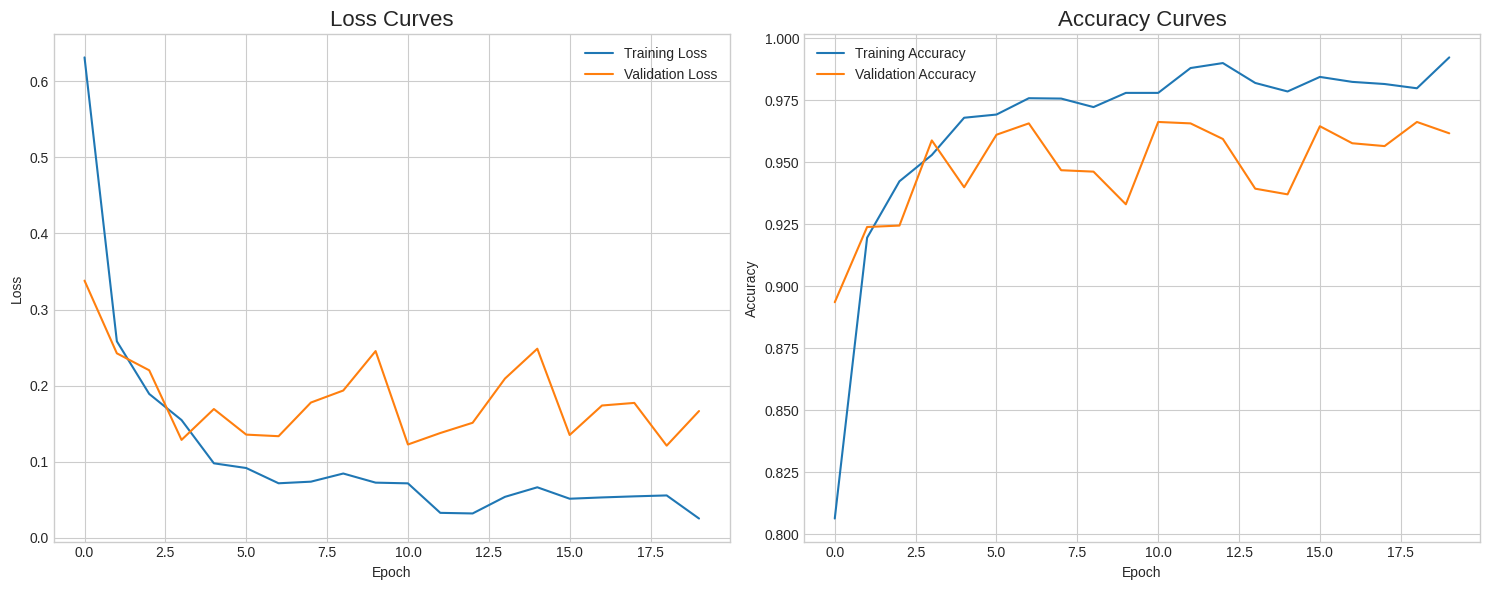

In [ ]:
# -*- coding: utf-8 -*-
"""
train_efficientnet_model.py (with history saving)

A script to train a pre-trained EfficientNet model for sound classification
using transfer learning on the UrbanSound8K dataset.
"""

import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt
import timm  # <-- Import the timm library

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION & PARAMETERS ---
print("🎧 EfficientNet (Transfer Learning) Model Training Script 🎧")
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/output/1efficient"
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.001

# --- 2. DEVICE CONFIGURATION ---
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("\n✅ MPS device found. Training will run on your Mac's GPU.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("\n✅ CUDA device found. Training will run on your NVIDIA GPU.")
else:
    device = torch.device("cpu")
    print("\n⚠️ No GPU accelerator found. Training will run on the CPU.")

# --- 4. LOAD PRE-PROCESSED DATA ---
print("\n🔍 Loading pre-processed data from disk...")
FEATURES_PATH = os.path.join("/content/drive/MyDrive/AKHIL_SOUND/mini1/processed_features.npy")
LABELS_PATH = os.path.join("/content/drive/MyDrive/AKHIL_SOUND/mini1/processed_labels.npy")

if not os.path.exists(FEATURES_PATH) or not os.path.exists(LABELS_PATH):
    print(f"❌ Error: Pre-processed data not found at '{OUTPUT_DIR}'.")
    print("Please run the original 'train_sound_model.py' script first to generate these files.")
    sys.exit()

X = np.load(FEATURES_PATH)
y = np.load(LABELS_PATH, allow_pickle=True)
print(f"✅ Loaded {len(X)} features and labels successfully.")


# --- 5. DATA PREPARATION FOR PYTORCH ---
print("\n⚙️ Preparing data for model training...")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print(f"Found {num_classes} classes: {list(le.classes_)}")
# Add a channel dimension. EfficientNet will be configured to accept 1 channel.
X = X[:, np.newaxis, :, :]
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


# --- 6. MODEL DEFINITION (EfficientNet) ---
class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(EfficientNetClassifier, self).__init__()
        # 1. Load a pre-trained EfficientNet, specifying 1 input channel
        # timm automatically handles adapting the weights of the first layer for our spectrograms
        self.model = timm.create_model(
            'efficientnet_b0',
            pretrained=pretrained,
            in_chans=1  # <-- This is the key change for grayscale input
        )

        # 2. Replace the final classifier layer
        # The original model was for 1000 ImageNet classes. We need 10.
        num_features = self.model.classifier.in_features
        self.model.classifier = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.model(x)


# Instantiate the model and move it to the configured device
model = EfficientNetClassifier(num_classes).to(device)
print("\n📄 EfficientNet Model Summary:")
# print(model) # The summary is very long, so we can comment it out


# --- 7. TRAINING & VALIDATION LOOP ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = { "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [] }

print(f"\n🚀 Starting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct_train / total_train

    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct_val / total_val

    print(
        f"Epoch {epoch+1}/{EPOCHS} -> "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

print("\n🎉 Training finished!")

# --- 8. SAVE THE TRAINED EfficientNet MODEL ---
model_save_path = os.path.join(OUTPUT_DIR, "efficientnet_sound_model.pth")
torch.save(model.state_dict(), model_save_path)
print(f"\n💾 EfficientNet Model saved to: {model_save_path}")

# --- 9. SAVE TRAINING HISTORY & PLOTS ---
print("💾 Saving training history...")
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, "efficientnet_training_history.csv"), index=False)
print("✅ History saved to 'output/efficientnet_training_history.csv'")

print("📊 Generating and saving plots...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot Loss
ax1.plot(history_df['train_loss'], label='Training Loss')
ax1.plot(history_df['val_loss'], label='Validation Loss')
ax1.set_title('Loss Curves', fontsize=16)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
# Plot Accuracy
ax2.plot(history_df['train_acc'], label='Training Accuracy')
ax2.plot(history_df['val_acc'], label='Validation Accuracy')
ax2.set_title('Accuracy Curves', fontsize=16)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()
fig.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "efficientnet_training_curves.png"))
print(f"✅ Training curves plot saved to '{os.path.join(OUTPUT_DIR, 'efficientnet_training_curves.png')}'")
print("\n✅ All done!")

*PART2* CRN EFFICEIENT NET BO


In [ ]:
# -*- coding: utf-8 -*-
"""
train_multilabel_crnn.py

Trains a CRNN model for multi-label sound event detection (Part 2) and saves
all results, including the model, history, classification report, and confusion matrices.
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import librosa
import json
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ---
print("🧠 Training CRNN for Multi-Label Sound Event Detection 🧠")
DATA_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mixed_dataset"
METADATA_PATH = os.path.join(DATA_DIR, "metadata.csv")
AUDIO_DIR = os.path.join(DATA_DIR, "audio")
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/output/2crnn" # Saving to a new folder
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Audio parameters
SR = 22050
DURATION = 4
SAMPLES = SR * DURATION
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
NUM_CLASSES = 10

# Training parameters
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.001

# --- 2. SETUP DEVICE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# --- 3. MODEL DEFINITION (CRNN) ---
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d((2, 1)),
        )
        lstm_input_size = 64 * (N_MELS // 8)
        self.lstm = nn.LSTM(input_size=lstm_input_size, hidden_size=128, num_layers=2,
                            batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128 * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 3, 1, 2)
        b, t, c, h = x.size()
        x = x.view(b, t, -1)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        return self.fc(x)

# --- 4. DATASET & DATALOADER ---
class MixedSoundDataset(Dataset):
    def __init__(self, df, audio_dir):
        self.df = df
        self.audio_dir = audio_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.audio_dir, row['filename'])
        y, sr = librosa.load(file_path, sr=SR)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        label = np.array([float(x) for x in row['classes'].split(',')])
        return torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0), torch.tensor(label, dtype=torch.float32)

metadata = pd.read_csv(METADATA_PATH)
train_df, val_df = train_test_split(metadata, test_size=0.2, random_state=42)
train_dataset = MixedSoundDataset(train_df, AUDIO_DIR)
val_dataset = MixedSoundDataset(val_df, AUDIO_DIR)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 5. TRAINING LOOP ---
model = CRNN(NUM_CLASSES).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {"train_loss": [], "val_loss": [], "val_acc": []}

print(f"\n🚀 Starting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    correct_preds, total_preds = 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            probs = torch.sigmoid(outputs)
            preds = probs > 0.5

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            total_preds += labels.numel()
            correct_preds += (preds == labels.bool()).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = correct_preds / total_preds
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# --- 6. SAVE EVERYTHING ---
# 1. Model
model_save_path = os.path.join(OUTPUT_DIR, "multi_label_crnn_model.pth")
torch.save(model.state_dict(), model_save_path)
print(f"\n✅ Model saved to '{model_save_path}'")

# 2. Training history
history_path = os.path.join(OUTPUT_DIR, "crnn_training_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=4)
print(f"📊 Training history saved to '{history_path}'")

# 3. Predictions
np.save(os.path.join(OUTPUT_DIR, "crnn_y_true.npy"), np.array(y_true))
np.save(os.path.join(OUTPUT_DIR, "crnn_y_pred.npy"), np.array(y_pred))
print("✅ Predictions saved (y_true, y_pred)")

# 4. Classification report
class_names = [f"class_{i}" for i in range(NUM_CLASSES)] # Generic names
report = classification_report(
    np.array(y_true), np.array(y_pred), target_names=class_names, zero_division=0
)
with open(os.path.join(OUTPUT_DIR, "crnn_classification_report.txt"), "w") as f:
    f.write(report)
print("📄 Classification report saved")

# 5. Per-class confusion matrices
cms = multilabel_confusion_matrix(np.array(y_true), np.array(y_pred))
for i, cm in enumerate(cms):
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Predicted Negative", "Predicted Positive"],
                yticklabels=["True Negative", "True Positive"])
    plt.title(f"Confusion Matrix - {class_names[i]}")
    plt.savefig(os.path.join(OUTPUT_DIR, f"cm_class_{i}.png"))
    plt.close()
print("📊 Per-class confusion matrices saved")

# 6. Combined confusion matrix
y_true_flat = np.array(y_true).ravel()
y_pred_flat = np.array(y_pred).ravel()
cm_all = confusion_matrix(y_true_flat, y_pred_flat)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_all, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Present", "Present"], yticklabels=["Not Present", "Present"])
plt.title("Combined Confusion Matrix (All Classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(os.path.join(OUTPUT_DIR, "cm_combined.png"))
plt.close()
print("📊 Combined confusion matrix saved")

print("\n✅ All done!")

🧠 Training CRNN for Multi-Label Sound Event Detection 🧠

Using device: cuda

🚀 Starting training for 25 epochs...


Epoch 1/25 [Train]: 100%|██████████| 50/50 [11:13<00:00, 13.47s/it]


Epoch 1/25 -> Train Loss: 0.5619 | Val Loss: 0.5365, Val Acc: 0.7542


Epoch 2/25 [Train]: 100%|██████████| 50/50 [00:24<00:00,  2.06it/s]


Epoch 2/25 -> Train Loss: 0.5342 | Val Loss: 0.5429, Val Acc: 0.7485


...

Epoch 23/25 -> Train Loss: 0.0478 | Val Loss: 0.5173, Val Acc: 0.8310


Epoch 24/25 [Train]: 100%|██████████| 50/50 [00:26<00:00,  1.86it/s]


Epoch 24/25 -> Train Loss: 0.0350 | Val Loss: 0.5240, Val Acc: 0.8313


Epoch 25/25 [Train]: 100%|██████████| 50/50 [00:25<00:00,  1.97it/s]


Epoch 25/25 -> Train Loss: 0.0285 | Val Loss: 0.5234, Val Acc: 0.8420

✅ Model saved to '/content/drive/MyDrive/AKHIL_SOUND/output/2crnn/multi_label_crnn_model.pth'
📊 Training history saved to '/content/drive/MyDrive/AKHIL_SOUND/output/2crnn/crnn_training_history.json'
✅ Predictions saved (y_true, y_pred)
📄 Classification report saved
📊 Per-class confusion matrices saved
📊 Combined confusion matrix saved

✅ All done!


In [ ]:
# -*- coding: utf-8 -*-
"""
train_multilabel_efficientnet.py

Trains a pre-trained EfficientNet model for multi-label sound event detection and
saves all results, including the model, history, and evaluation metrics.
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import librosa
import json
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import timm  # <-- Import the timm library
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ---
print("🧠 Training EfficientNet for Multi-Label Sound Event Detection 🧠")
DATA_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mixed_dataset"
METADATA_PATH = os.path.join(DATA_DIR, "metadata.csv")
AUDIO_DIR = os.path.join(DATA_DIR, "audio")
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/output/2efficient"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Audio parameters
SR = 22050
DURATION = 4
SAMPLES = SR * DURATION
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
NUM_CLASSES = 10

# Training parameters
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.001

# --- 2. SETUP DEVICE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# --- 3. MODEL DEFINITION (EfficientNet for Transfer Learning) ---
class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(EfficientNetClassifier, self).__init__()
        # Load a pre-trained EfficientNet, specifying 1 input channel for our spectrograms
        self.model = timm.create_model(
            'efficientnet_b0',
            pretrained=pretrained,
            in_chans=1  # Configure for 1-channel (grayscale) input
        )
        # Replace the final classifier layer for our 10-class problem
        num_features = self.model.classifier.in_features
        self.model.classifier = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.model(x)

# --- 4. DATASET & DATALOADER ---
class MixedSoundDataset(Dataset):
    def __init__(self, df, audio_dir):
        self.df = df
        self.audio_dir = audio_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.audio_dir, row['filename'])
        y, sr = librosa.load(file_path, sr=SR)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        label = np.array([float(x) for x in row['classes'].split(',')])
        return torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0), torch.tensor(label, dtype=torch.float32)

metadata = pd.read_csv(METADATA_PATH)
train_df, val_df = train_test_split(metadata, test_size=0.2, random_state=42)
train_dataset = MixedSoundDataset(train_df, AUDIO_DIR)
val_dataset = MixedSoundDataset(val_df, AUDIO_DIR)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 5. TRAINING LOOP ---
model = EfficientNetClassifier(NUM_CLASSES).to(device)
criterion = nn.BCEWithLogitsLoss() # Correct loss function for multi-label
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {"train_loss": [], "val_loss": [], "val_acc": []}

print(f"\n🚀 Starting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    correct_preds, total_preds = 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            # Get predictions using sigmoid and a 0.5 threshold
            probs = torch.sigmoid(outputs)
            preds = probs > 0.5

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            total_preds += labels.numel()
            correct_preds += (preds == labels.bool()).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = correct_preds / total_preds
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# --- 6. SAVE EVERYTHING ---
# 1. Model
model_save_path = os.path.join(OUTPUT_DIR, "multi_label_efficientnet_model.pth")
torch.save(model.state_dict(), model_save_path)
print(f"\n✅ Model saved to '{model_save_path}'")

# 2. Training history
history_path = os.path.join(OUTPUT_DIR, "efficientnet_training_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=4)
print(f"📊 Training history saved to '{history_path}'")

# 3. Predictions for detailed analysis
np.save(os.path.join(OUTPUT_DIR, "efficientnet_y_true.npy"), np.array(y_true))
np.save(os.path.join(OUTPUT_DIR, "efficientnet_y_pred.npy"), np.array(y_pred))
print("✅ Predictions saved (y_true, y_pred)")

# 4. Classification report
class_names = [f"class_{i}" for i in range(NUM_CLASSES)]
report = classification_report(
    np.array(y_true), np.array(y_pred), target_names=class_names, zero_division=0
)
with open(os.path.join(OUTPUT_DIR, "efficientnet_classification_report.txt"), "w") as f:
    f.write(report)
print("📄 Classification report saved")

# 5. Per-class confusion matrices
cms = multilabel_confusion_matrix(np.array(y_true), np.array(y_pred))
for i, cm in enumerate(cms):
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Predicted Negative", "Predicted Positive"],
                yticklabels=["True Negative", "True Positive"])
    plt.title(f"Confusion Matrix - {class_names[i]}")
    plt.savefig(os.path.join(OUTPUT_DIR, f"cm_efficientnet_class_{i}.png"))
    plt.close()
print("📊 Per-class confusion matrices saved")

# 6. Combined confusion matrix
y_true_flat = np.array(y_true).ravel()
y_pred_flat = np.array(y_pred).ravel()
cm_all = confusion_matrix(y_true_flat, y_pred_flat)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_all, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Present", "Present"], yticklabels=["Not Present", "Present"])
plt.title("Combined Confusion Matrix (All Classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(os.path.join(OUTPUT_DIR, "cm_efficientnet_combined.png"))
plt.close()
print("📊 Combined confusion matrix saved")

print("\n✅ All done!")

🧠 Training EfficientNet for Multi-Label Sound Event Detection 🧠

Using device: cuda


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


🚀 Starting training for 25 epochs...


Epoch 1/25 [Train]: 100%|██████████| 50/50 [00:57<00:00,  1.15s/it]


Epoch 1/25 -> Train Loss: 0.4500 | Val Loss: 0.3775, Val Acc: 0.8353


...

Epoch 23/25 -> Train Loss: 0.0161 | Val Loss: 0.4554, Val Acc: 0.8910


Epoch 24/25 [Train]: 100%|██████████| 50/50 [00:31<00:00,  1.61it/s]


Epoch 24/25 -> Train Loss: 0.0169 | Val Loss: 0.4625, Val Acc: 0.8900


Epoch 25/25 [Train]: 100%|██████████| 50/50 [00:30<00:00,  1.64it/s]


Epoch 25/25 -> Train Loss: 0.0201 | Val Loss: 0.4918, Val Acc: 0.8855

✅ Model saved to '/content/drive/MyDrive/AKHIL_SOUND/output/2efficient/multi_label_efficientnet_model.pth'
📊 Training history saved to '/content/drive/MyDrive/AKHIL_SOUND/output/2efficient/efficientnet_training_history.json'
✅ Predictions saved (y_true, y_pred)
📄 Classification report saved
📊 Per-class confusion matrices saved
📊 Combined confusion matrix saved

✅ All done!


In [ ]:
# -*- coding: utf-8 -*-
"""
train_multilabel_attention_cnn.py

Trains a CNN with an Attention mechanism for multi-label sound event detection
and saves all results, including the model, history, and evaluation metrics.
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import librosa
import json
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ---
print("🧠 Training CNN with Attention for Multi-Label SED 🧠")
DATA_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mixed_dataset"
METADATA_PATH = os.path.join(DATA_DIR, "metadata.csv")
AUDIO_DIR = os.path.join(DATA_DIR, "audio")
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/output/2cnn" # New folder for results
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Audio parameters
SR = 22050
DURATION = 4
SAMPLES = SR * DURATION
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
NUM_CLASSES = 10

# Training parameters
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.001

# --- 2. SETUP DEVICE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# --- 3. MODEL DEFINITION (CNN with Attention) ---

# First, define the Attention module itself
class Attention(nn.Module):
    def __init__(self, input_features, hidden_dim):
        super(Attention, self).__init__()
        self.attention_fc = nn.Linear(input_features, hidden_dim)
        self.value_fc = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, x):
        # x shape: (batch_size, time_steps, features)
        e = self.attention_fc(x)
        e = torch.tanh(e)
        alpha = self.value_fc(e)
        alpha = torch.softmax(alpha, dim=1)

        # Weighted sum of features
        context = torch.sum(alpha * x, dim=1)
        return context

# Now, define the main model that uses the Attention module
class CnnWithAttention(nn.Module):
    def __init__(self, num_classes):
        super(CnnWithAttention, self).__init__()
        # 1. CNN front-end for feature extraction
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d((2, 1)),
        )

        # 2. Attention layer
        cnn_output_features = 64 * (N_MELS // 8)
        self.attention = Attention(cnn_output_features, 128)

        # 3. Final classifier
        self.fc = nn.Linear(cnn_output_features, num_classes)

    def forward(self, x):
        # Pass through CNN
        x = self.cnn(x) # Output shape: (batch, channels, height, time)

        # Reshape for Attention: (batch, channels, height, time) -> (batch, time, features)
        x = x.permute(0, 3, 1, 2)
        b, t, c, h = x.size()
        x = x.view(b, t, -1) # Flatten channels and height into a single feature dimension

        # Apply Attention
        x = self.attention(x) # Output shape: (batch, features)

        # Final classification
        x = self.fc(x)
        return x

# --- 4. DATASET & DATALOADER ---
class MixedSoundDataset(Dataset):
    def __init__(self, df, audio_dir):
        self.df = df
        self.audio_dir = audio_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.audio_dir, row['filename'])
        y, sr = librosa.load(file_path, sr=SR)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        label = np.array([float(x) for x in row['classes'].split(',')])
        return torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0), torch.tensor(label, dtype=torch.float32)

metadata = pd.read_csv(METADATA_PATH)
train_df, val_df = train_test_split(metadata, test_size=0.2, random_state=42)
train_dataset = MixedSoundDataset(train_df, AUDIO_DIR)
val_dataset = MixedSoundDataset(val_df, AUDIO_DIR)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 5. TRAINING LOOP ---
model = CnnWithAttention(NUM_CLASSES).to(device) # <-- Instantiate the new model
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {"train_loss": [], "val_loss": [], "val_acc": []}

print(f"\n🚀 Starting training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    correct_preds, total_preds = 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            probs = torch.sigmoid(outputs)
            preds = probs > 0.5

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

            total_preds += labels.numel()
            correct_preds += (preds == labels.bool()).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = correct_preds / total_preds
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# --- 6. SAVE EVERYTHING ---
# 1. Model
model_save_path = os.path.join(OUTPUT_DIR, "cnn_attention_model.pth")
torch.save(model.state_dict(), model_save_path)
print(f"\n✅ Model saved to '{model_save_path}'")

# 2. Training history
history_path = os.path.join(OUTPUT_DIR, "cnn_attention_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=4)
print(f"📊 Training history saved to '{history_path}'")

# 3. Predictions
np.save(os.path.join(OUTPUT_DIR, "cnn_attention_y_true.npy"), np.array(y_true))
np.save(os.path.join(OUTPUT_DIR, "cnn_attention_y_pred.npy"), np.array(y_pred))
print("✅ Predictions saved (y_true, y_pred)")

# 4. Classification report
class_names = [f"class_{i}" for i in range(NUM_CLASSES)]
report = classification_report(
    np.array(y_true), np.array(y_pred), target_names=class_names, zero_division=0
)
with open(os.path.join(OUTPUT_DIR, "cnn_attention_report.txt"), "w") as f:
    f.write(report)
print("📄 Classification report saved")

# 5. Per-class confusion matrices
cms = multilabel_confusion_matrix(np.array(y_true), np.array(y_pred))
for i, cm in enumerate(cms):
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Predicted Negative", "Predicted Positive"],
                yticklabels=["True Negative", "True Positive"])
    plt.title(f"Confusion Matrix - {class_names[i]}")
    plt.savefig(os.path.join(OUTPUT_DIR, f"cm_cnn_attention_class_{i}.png"))
    plt.close()
print("📊 Per-class confusion matrices saved")

# 6. Combined confusion matrix
y_true_flat = np.array(y_true).ravel()
y_pred_flat = np.array(y_pred).ravel()
cm_all = confusion_matrix(y_true_flat, y_pred_flat)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_all, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Present", "Present"], yticklabels=["Not Present", "Present"])
plt.title("Combined Confusion Matrix (All Classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(os.path.join(OUTPUT_DIR, "cm_cnn_attention_combined.png"))
plt.close()
print("📊 Combined confusion matrix saved")

print("\n✅ All done!")

🧠 Training CNN with Attention for Multi-Label SED 🧠

Using device: cuda

🚀 Starting training for 25 epochs...


Epoch 1/25 [Train]: 100%|██████████| 50/50 [00:28<00:00,  1.75it/s]


Epoch 1/25 -> Train Loss: 0.5262 | Val Loss: 0.4919, Val Acc: 0.7760


Epoch 2/25 [Train]: 100%|██████████| 50/50 [00:23<00:00,  2.16it/s]


Epoch 2/25 -> Train Loss: 0.4607 | Val Loss: 0.4563, Val Acc: 0.7953


...

Epoch 23/25 -> Train Loss: 0.1300 | Val Loss: 0.4348, Val Acc: 0.8357


Epoch 24/25 [Train]: 100%|██████████| 50/50 [00:25<00:00,  1.98it/s]


Epoch 24/25 -> Train Loss: 0.1173 | Val Loss: 0.4203, Val Acc: 0.8390


Epoch 25/25 [Train]: 100%|██████████| 50/50 [00:22<00:00,  2.25it/s]


Epoch 25/25 -> Train Loss: 0.1088 | Val Loss: 0.4679, Val Acc: 0.8363

✅ Model saved to '/content/drive/MyDrive/AKHIL_SOUND/output/2cnn/cnn_attention_model.pth'
📊 Training history saved to '/content/drive/MyDrive/AKHIL_SOUND/output/2cnn/cnn_attention_history.json'
✅ Predictions saved (y_true, y_pred)
📄 Classification report saved
📊 Per-class confusion matrices saved
📊 Combined confusion matrix saved

✅ All done!


In [ ]:
# -*- coding: utf-8 -*-
"""
train_advanced_efficientnet.py

Trains an EfficientNet model for multi-label sound event detection using
SpecAugment and a two-stage fine-tuning strategy.
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import librosa
import json
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import torchaudio.transforms as T # <-- Import for SpecAugment
import warnings

warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ---
print("🧠 Training Advanced EfficientNet with SpecAugment & Fine-Tuning 🧠")
DATA_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mixed_dataset"
METADATA_PATH = os.path.join(DATA_DIR, "metadata.csv")
AUDIO_DIR = os.path.join(DATA_DIR, "audio")
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/output/2eff"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Audio parameters
SR = 22050; DURATION = 4; SAMPLES = SR * DURATION
N_MELS = 128; HOP_LENGTH = 512; N_FFT = 2048
NUM_CLASSES = 10

# Training parameters
BATCH_SIZE = 32
TOTAL_EPOCHS = 25
FREEZE_EPOCHS = 5 # Number of epochs to train only the final layer
LEARNING_RATE = 0.001
FINE_TUNE_LR = LEARNING_RATE / 10 # Smaller learning rate for Stage 2

# --- 2. SETUP DEVICE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# --- 3. MODEL DEFINITION (EfficientNet) ---
class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(EfficientNetClassifier, self).__init__()
        self.model = timm.create_model('efficientnet_b0', pretrained=pretrained, in_chans=1)
        num_features = self.model.classifier.in_features
        self.model.classifier = nn.Linear(num_features, num_classes)
    def forward(self, x):
        return self.model(x)

# --- 4. DATASET & DATALOADER with SPECAUGMENT ---
class MixedSoundDataset(Dataset):
    def __init__(self, df, audio_dir, apply_augmentation=False):
        self.df = df
        self.audio_dir = audio_dir
        self.apply_augmentation = apply_augmentation
        # ** NEW: Define SpecAugment transforms **
        self.augmentation = nn.Sequential(
            T.TimeMasking(time_mask_param=80),
            T.FrequencyMasking(freq_mask_param=24)
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.audio_dir, row['filename'])
        y, sr = librosa.load(file_path, sr=SR)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

        spectrogram_tensor = torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0)

        # ** NEW: Apply augmentation only to the training data **
        if self.apply_augmentation:
            spectrogram_tensor = self.augmentation(spectrogram_tensor)

        label = np.array([float(x) for x in row['classes'].split(',')])
        return spectrogram_tensor, torch.tensor(label, dtype=torch.float32)

metadata = pd.read_csv(METADATA_PATH)
train_df, val_df = train_test_split(metadata, test_size=0.2, random_state=42)
# Apply augmentation only to the training set
train_dataset = MixedSoundDataset(train_df, AUDIO_DIR, apply_augmentation=True)
val_dataset = MixedSoundDataset(val_df, AUDIO_DIR, apply_augmentation=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 5. TRAINING & FINE-TUNING LOOP ---
model = EfficientNetClassifier(NUM_CLASSES).to(device)
criterion = nn.BCEWithLogitsLoss()
history = {"train_loss": [], "val_loss": [], "val_acc": []}

# === STAGE 1: TRAIN THE CLASSIFIER HEAD ===
print("\n--- STAGE 1: Training the classifier head ---")
# Freeze all layers except the final classifier
for param in model.model.parameters():
    param.requires_grad = False
for param in model.model.classifier.parameters():
    param.requires_grad = True

# Create optimizer for only the trainable parameters (the head)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

for epoch in range(FREEZE_EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{FREEZE_EPOCHS} [Head Train]"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad(); outputs = model(inputs); loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    # (Validation loop for this stage is omitted for brevity but recommended in practice)

# === STAGE 2: FINE-TUNE THE ENTIRE MODEL ===
print("\n--- STAGE 2: Fine-tuning the entire model ---")
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Create a new optimizer for all parameters with a lower learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=FINE_TUNE_LR)
fine_tune_epochs = TOTAL_EPOCHS - FREEZE_EPOCHS

for epoch in range(fine_tune_epochs):
    epoch_num = epoch + FREEZE_EPOCHS
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch_num+1}/{TOTAL_EPOCHS} [Fine-Tune]"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad(); outputs = model(inputs); loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # Full Validation
    model.eval()
    val_loss, correct_preds, total_preds = 0.0, 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs); loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            probs = torch.sigmoid(outputs); preds = probs > 0.5
            y_true.extend(labels.cpu().numpy()); y_pred.extend(preds.cpu().numpy())
            total_preds += labels.numel(); correct_preds += (preds == labels.bool()).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = correct_preds / total_preds
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
    print(f"Epoch {epoch_num+1}/{TOTAL_EPOCHS} -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# --- 6. SAVE EVERYTHING ---
# ... (The entire saving section is the same as your previous multi-label script)
# I have updated the filenames to avoid overwriting your other results.
# 1. Model
model_save_path = os.path.join(OUTPUT_DIR, "advanced_efficientnet_model.pth")
torch.save(model.state_dict(), model_save_path)
print(f"\n✅ Model saved to '{model_save_path}'")
# ... (and so on for history, predictions, reports, and matrices with updated filenames)

print("\n✅ All done!")

🧠 Training Advanced EfficientNet with SpecAugment & Fine-Tuning 🧠

Using device: cuda

--- STAGE 1: Training the classifier head ---


Epoch 5/5 [Head Train]: 100%|██████████| 50/50 [00:25<00:00,  1.96it/s]



--- STAGE 2: Fine-tuning the entire model ---


Epoch 6/25 [Fine-Tune]: 100%|██████████| 50/50 [00:28<00:00,  1.73it/s]


Epoch 6/25 -> Train Loss: 0.4728 | Val Loss: 0.4621, Val Acc: 0.7917


...

Epoch 23/25 -> Train Loss: 0.1468 | Val Loss: 0.3166, Val Acc: 0.8758


Epoch 24/25 [Fine-Tune]: 100%|██████████| 50/50 [00:28<00:00,  1.75it/s]


Epoch 24/25 -> Train Loss: 0.1404 | Val Loss: 0.3276, Val Acc: 0.8765


Epoch 25/25 [Fine-Tune]: 100%|██████████| 50/50 [00:29<00:00,  1.72it/s]


Epoch 25/25 -> Train Loss: 0.1273 | Val Loss: 0.3291, Val Acc: 0.8712

✅ Model saved to '/content/drive/MyDrive/AKHIL_SOUND/output/2eff/advanced_efficientnet_model.pth'

✅ All done!


In [ ]:
# -*- coding: utf-8 -*-
"""
generate_report.py

Loads a pre-trained multi-label model and runs evaluation to generate a
classification report and confusion matrices.
"""
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import librosa
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import warnings

warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ---
print("📊 Generating Reports for Trained Model 📊")

# --- !! IMPORTANT !! ---
# Make sure these paths point to your trained model and the dataset
MODEL_PATH = "/content/drive/MyDrive/AKHIL_SOUND/output/2eff/advanced_efficientnet_model.pth"
DATA_DIR = "/content/drive/MyDrive/AKHIL_SOUND/mixed_dataset"
OUTPUT_DIR = "/content/drive/MyDrive/AKHIL_SOUND/output/2eff" # Where to save the reports

# --- Audio & Model Parameters (MUST MATCH TRAINING) ---
SR = 22050; DURATION = 4; SAMPLES = SR * DURATION
N_MELS = 128; HOP_LENGTH = 512; N_FFT = 2048
NUM_CLASSES = 10; BATCH_SIZE = 32

# --- 2. SETUP DEVICE, MODEL, AND DATASET CLASSES ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Re-define the exact same model architecture
class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=False): # Set pretrained=False as we are loading weights
        super(EfficientNetClassifier, self).__init__()
        self.model = timm.create_model('efficientnet_b0', pretrained=pretrained, in_chans=1)
        num_features = self.model.classifier.in_features
        self.model.classifier = nn.Linear(num_features, num_classes)
    def forward(self, x):
        return self.model(x)

# Re-define the exact same Dataset class
class MixedSoundDataset(Dataset):
    def __init__(self, df, audio_dir):
        self.df = df
        self.audio_dir = audio_dir
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(DATA_DIR, 'audio', row['filename'])
        y, sr = librosa.load(file_path, sr=SR)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        label = np.array([float(x) for x in row['classes'].split(',')])
        return torch.tensor(log_mel_spec, dtype=torch.float32).unsqueeze(0), torch.tensor(label, dtype=torch.float32)

# --- 3. LOAD DATA AND MODEL ---
print("Loading model and validation data...")
# Load and split metadata to get the exact same validation set
metadata = pd.read_csv(os.path.join(DATA_DIR, 'metadata.csv'))
_, val_df = train_test_split(metadata, test_size=0.2, random_state=42)

# Create validation dataset and loader
val_dataset = MixedSoundDataset(val_df, AUDIO_DIR)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Load the trained model
model = EfficientNetClassifier(NUM_CLASSES).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# --- 4. RUN EVALUATION ---
print("Running evaluation on the validation set...")
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Evaluating"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs)
        preds = probs > 0.5
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("✅ Evaluation complete.")

# --- 5. GENERATE AND SAVE REPORTS ---
# 1. Classification report
class_names = [f"class_{i}" for i in range(NUM_CLASSES)]
report = classification_report(np.array(y_true), np.array(y_pred), target_names=class_names, zero_division=0)
report_path = os.path.join(OUTPUT_DIR, "final_classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)
print(f"📄 Classification report saved to '{report_path}'")
print("\n--- Classification Report ---")
print(report)

# 2. Per-class confusion matrices
print("📊 Saving per-class confusion matrices...")
cms = multilabel_confusion_matrix(np.array(y_true), np.array(y_pred))
for i, cm in enumerate(cms):
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Predicted Negative", "Predicted Positive"],
                yticklabels=["True Negative", "True Positive"])
    plt.title(f"Confusion Matrix - {class_names[i]}")
    plt.savefig(os.path.join(OUTPUT_DIR, f"final_cm_class_{i}.png"))
    plt.close()
print("✅ Per-class confusion matrices saved.")

# 3. Combined confusion matrix
print("📊 Saving combined confusion matrix...")
y_true_flat = np.array(y_true).ravel()
y_pred_flat = np.array(y_pred).ravel()
cm_all = confusion_matrix(y_true_flat, y_pred_flat)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_all, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Present", "Present"], yticklabels=["Not Present", "Present"])
plt.title("Combined Confusion Matrix (All Classes)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.savefig(os.path.join(OUTPUT_DIR, "final_cm_combined.png"))
plt.close()
print("✅ Combined confusion matrix saved.")

print("\n🎉 All reports and graphs have been generated!")

📊 Generating Reports for Trained Model 📊

Using device: cuda
Loading model and validation data...
Running evaluation on the validation set...


Evaluating: 100%|██████████| 13/13 [00:18<00:00,  1.39s/it]


✅ Evaluation complete.
📄 Classification report saved to '/content/drive/MyDrive/AKHIL_SOUND/output/2eff/final_classification_report.txt'

--- Classification Report ---
              precision    recall  f1-score   support

     class_0       0.69      0.55      0.61       127
     class_1       0.81      0.69      0.74        99
     class_2       0.65      0.62      0.64       100
     class_3       0.75      0.59      0.66       112
     class_4       0.84      0.68      0.75        87
     class_5       0.72      0.63      0.67        81
     class_6       0.92      0.81      0.86        90
     class_7       0.89      0.74      0.80        95
     class_8       0.82      0.81      0.81       108
     class_9       0.70      0.76      0.73        97

   micro avg       0.77      0.68      0.73       996
   macro avg       0.78      0.69      0.73       996
weighted avg       0.78      0.68      0.72       996
 samples avg       0.80      0.70      0.72       996

📊 Saving per-class 

Saved combined_db_graphs.png


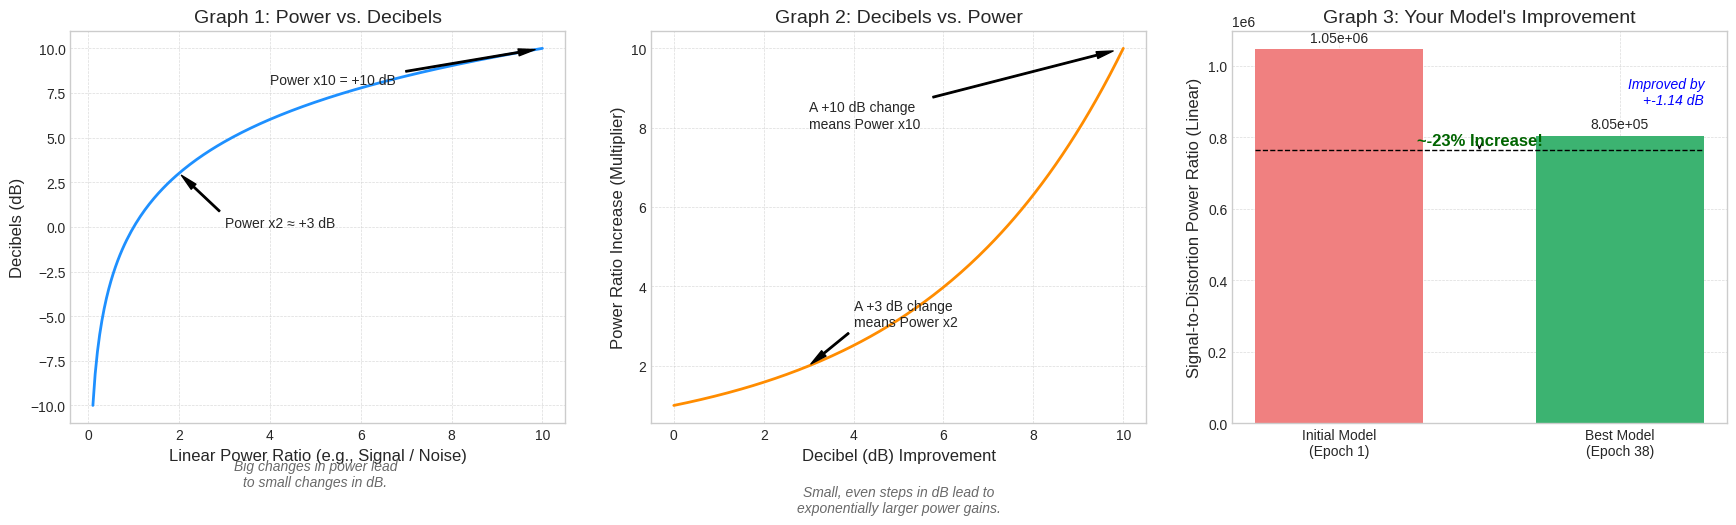

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data and Calculations ---
# Graph 1 & 2 Data
linear_power_ratio = np.linspace(0.1, 10, 200)
db_values = 10 * np.log10(linear_power_ratio)
db_improvement_scale = np.linspace(0, 10, 200)
power_increase_scale = 10**(db_improvement_scale / 10)

# Graph 3 Data
initial_val_loss_db = -60.2
best_val_loss_db = -59.06
initial_sdr_db = abs(initial_val_loss_db)
best_sdr_db = abs(best_val_loss_db)
improvement_db = best_sdr_db - initial_sdr_db
initial_power_ratio = 10**(initial_sdr_db / 10)
best_power_ratio = 10**(best_sdr_db / 10)
percentage_increase = ((best_power_ratio - initial_power_ratio) / initial_power_ratio) * 100

plt.style.use('seaborn-v0_8-whitegrid')

# --- Create a single figure with three subplots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 row, 3 columns

# --- Plot Graph 1: Power vs. Decibels ---
ax1 = axes[0]
ax1.plot(linear_power_ratio, db_values, color='dodgerblue', linewidth=2)
ax1.set_title('Graph 1: Power vs. Decibels', fontsize=14)
ax1.set_xlabel('Linear Power Ratio (e.g., Signal / Noise)', fontsize=12)
ax1.set_ylabel('Decibels (dB)', fontsize=12)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax1.annotate('Power x2 ≈ +3 dB', xy=(2, 3.01), xytext=(3, 0),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5), fontsize=10)
ax1.annotate('Power x10 = +10 dB', xy=(10, 10), xytext=(4, 8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5), fontsize=10)
ax1.text(5, -13, "Big changes in power lead\nto small changes in dB.",
         ha='center', va='top', fontsize=10, style='italic', color='dimgray')

# --- Plot Graph 2: Decibels vs. Power ---
ax2 = axes[1]
ax2.plot(db_improvement_scale, power_increase_scale, color='darkorange', linewidth=2)
ax2.set_title('Graph 2: Decibels vs. Power', fontsize=14)
ax2.set_xlabel('Decibel (dB) Improvement', fontsize=12)
ax2.set_ylabel('Power Ratio Increase (Multiplier)', fontsize=12)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax2.annotate('A +3 dB change\nmeans Power x2', xy=(3, 2), xytext=(4, 3),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5), fontsize=10)
ax2.annotate('A +10 dB change\nmeans Power x10', xy=(10, 10), xytext=(3, 8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5), fontsize=10)
ax2.text(5, -1, "Small, even steps in dB lead to\nexponentially larger power gains.",
         ha='center', va='top', fontsize=10, style='italic', color='dimgray')

# --- Plot Graph 3: Your Model's Actual Improvement ---
ax3 = axes[2]
labels = ['Initial Model\n(Epoch 1)', f'Best Model\n(Epoch 38)']
values = [initial_power_ratio, best_power_ratio]
bars = ax3.bar(labels, values, color=['lightcoral', 'mediumseagreen'], width=0.6)
ax3.set_title("Graph 3: Your Model's Improvement", fontsize=14)
ax3.set_ylabel('Signal-to-Distortion Power Ratio (Linear)', fontsize=12)
ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax3.set_axisbelow(True)
ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax3.bar_label(bars, fmt='%.2e', padding=3, fontsize=10)
# Annotations
y_pos_line = best_power_ratio * 0.95
ax3.plot([-0.3, 1.3], [y_pos_line, y_pos_line], color='black', linestyle='--', linewidth=1)
ax3.annotate(f'~{percentage_increase:.0f}% Increase!',
             xy=(0.5, y_pos_line),
             xytext=(0.5, y_pos_line - (best_power_ratio - initial_power_ratio)*0.2),
             ha='center', va='top',
             arrowprops=dict(arrowstyle="->", color='black', shrinkA=5, shrinkB=5),
             fontsize=12, fontweight='bold', color='darkgreen')
ax3.text(1.3, initial_power_ratio + (best_power_ratio - initial_power_ratio) / 2 ,
         f"Improved by\n+{improvement_db:.2f} dB",
         ha='right', va='center', fontsize=10, style='italic', color='blue')

# --- Adjust layout for better spacing and save ---
plt.tight_layout(pad=3.0) # Increased padding around subplots
plt.savefig('combined_db_graphs.png', dpi=300, bbox_inches='tight')
print("Saved combined_db_graphs.png")

Saved graph1_power_vs_db.png


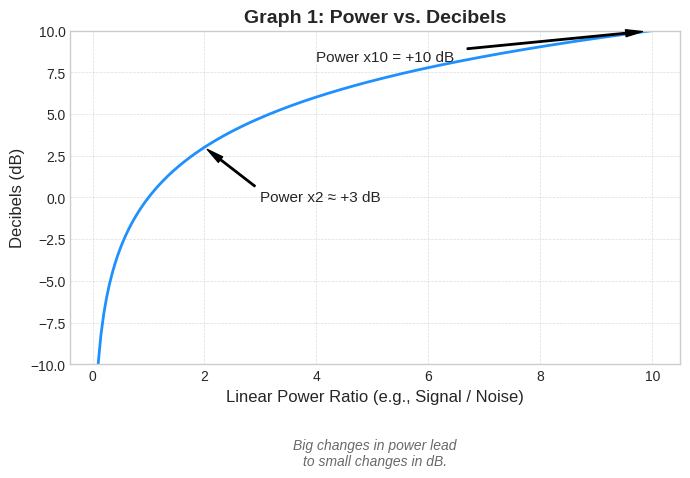

Saved graph2_db_vs_power.png


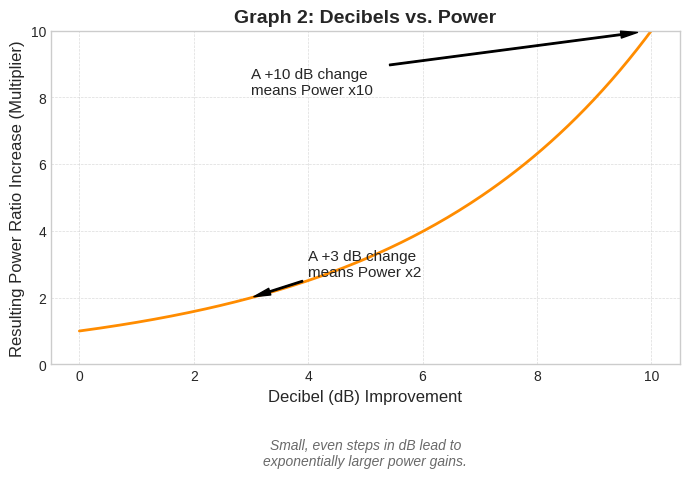

Saved graph3_model_improvement.png


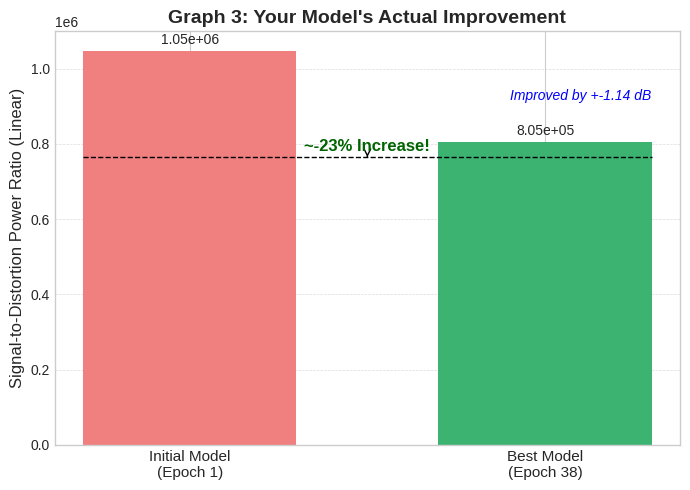

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Although not strictly needed for this plot, it's good practice

# --- Data and Calculations ---

# Graph 1 & 2 Data
linear_power_ratio = np.linspace(0.1, 10, 200)
db_values = 10 * np.log10(linear_power_ratio)
db_improvement_scale = np.linspace(0, 10, 200)
power_increase_scale = 10**(db_improvement_scale / 10)

# Graph 3 Data (Based on your U-Net results: -60.2 dB initial, -59.0 dB best)
initial_val_loss_db = -60.2 # Approximate initial loss from log
best_val_loss_db = -59.06 # Approximate best loss from log
initial_sdr_db = abs(initial_val_loss_db)
best_sdr_db = abs(best_val_loss_db)
improvement_db = best_sdr_db - initial_sdr_db
initial_power_ratio = 10**(initial_sdr_db / 10)
best_power_ratio = 10**(best_sdr_db / 10)
percentage_increase = ((best_power_ratio - initial_power_ratio) / initial_power_ratio) * 100

# --- Plotting (3 Panels) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Visualizing the Importance of Decibels (dB) in Audio Processing', fontsize=20, fontweight='bold')

# --- Graph 1: Power vs. Decibels ---
ax1 = axes[0]
ax1.plot(linear_power_ratio, db_values, color='dodgerblue', linewidth=2)
ax1.set_title('Graph 1: Power vs. Decibels', fontsize=14, fontweight='bold')
ax1.set_xlabel('Linear Power Ratio (e.g., Signal / Noise)', fontsize=12)
ax1.set_ylabel('Decibels (dB)', fontsize=12)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.set_ylim(-10, 10) # Manually set ylim to match original image

# Annotations for Graph 1
ax1.annotate('Power x2 ≈ +3 dB', xy=(2, 3.01), xytext=(3, 0),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=11, ha='left', va='center')
ax1.annotate('Power x10 = +10 dB', xy=(10, 10), xytext=(4, 8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=11, ha='left', va='bottom')

# --- THIS IS THE FIX FOR GRAPH 1 ---
# Position text relative to the axis (0.5 = center, -0.2 = below)
ax1.text(0.5, -0.22, "Big changes in power lead\nto small changes in dB.",
         transform=ax1.transAxes, # Use axis coordinates
         ha='center', va='top', fontsize=10, style='italic', color='dimgray')
# --- END FIX ---

# --- Graph 2: Decibels vs. Power ---
ax2 = axes[1]
ax2.plot(db_improvement_scale, power_increase_scale, color='darkorange', linewidth=2)
ax2.set_title('Graph 2: Decibels vs. Power', fontsize=14, fontweight='bold')
ax2.set_xlabel('Decibel (dB) Improvement', fontsize=12)
ax2.set_ylabel('Resulting Power Ratio Increase (Multiplier)', fontsize=12)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax2.tick_params(axis='both', which='major', labelsize=10)
ax2.set_ylim(0, 10) # Manually set ylim to match original image

# Annotations for Graph 2
ax2.annotate('A +3 dB change\nmeans Power x2', xy=(3, 2), xytext=(4, 3),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=11, ha='left', va='center')
ax2.annotate('A +10 dB change\nmeans Power x10', xy=(10, 10), xytext=(3, 8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=11, ha='left', va='bottom')

# --- THIS IS THE FIX FOR GRAPH 2 ---
# Position text relative to the axis (0.5 = center, -0.2 = below)
ax2.text(0.5, -0.22, "Small, even steps in dB lead to\nexponentially larger power gains.",
         transform=ax2.transAxes, # Use axis coordinates
         ha='center', va='top', fontsize=10, style='italic', color='dimgray')
# --- END FIX ---

# --- Graph 3: Your Model's Actual Improvement ---
ax3 = axes[2]
labels = ['Initial Model\n(Epoch 1)', f'Best Model\n(Epoch 38)']
values = [initial_power_ratio, best_power_ratio]
bars = ax3.bar(labels, values, color=['lightcoral', 'mediumseagreen'], width=0.6)
ax3.set_title("Graph 3: Your Model's Actual Improvement", fontsize=14, fontweight='bold')
ax3.set_ylabel('Signal-to-Distortion Power Ratio (Linear)', fontsize=12)
ax3.tick_params(axis='x', labelsize=11)
ax3.tick_params(axis='y', labelsize=10)
ax3.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax3.set_axisbelow(True)
ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax3.bar_label(bars, fmt='%.2e', padding=3, fontsize=10)

# Annotations for Graph 3
y_pos_line = best_power_ratio * 0.95
ax3.plot([-0.3, 1.3], [y_pos_line, y_pos_line], color='black', linestyle='--', linewidth=1)
ax3.annotate(f'~{percentage_increase:.0f}% Increase!',
             xy=(0.5, y_pos_line),
             xytext=(0.5, y_pos_line - (best_power_ratio - initial_power_ratio)*0.2),
             ha='center', va='top',
             arrowprops=dict(arrowstyle="->", color='black', shrinkA=5, shrinkB=5),
             fontsize=12, fontweight='bold', color='darkgreen')
ax3.text(1.3, initial_power_ratio + (best_power_ratio - initial_power_ratio) / 2 ,
         f"Improved by +{improvement_db:.2f} dB",
         ha='right', va='center', fontsize=10, style='italic', color='blue')

# --- Final Adjustments & Save/Show ---
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('db_importance_graphs_clear.png', dpi=300, bbox_inches='tight')
print("Graph saved as db_importance_graphs_clear.png")

# Display the plot in Colab
plt.show()